In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import ast
from sklearn.metrics import accuracy_score
import copy
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score,average_precision_score)
from sklearn.neural_network import MLPRegressor

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from scipy.stats import spearmanr
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance

# Load

In [54]:
path = "D:\\Research"

In [55]:
newness = np.load(f"{path}\\Creativity_Artnet\\Datasets\\newness_2024.npy",allow_pickle=True)
surprise = np.load(f"{path}\\Creativity_Artnet\\Datasets\\surprise_2024.npy",allow_pickle=True)
value = np.load(f"{path}\\Creativity_Artnet\\Datasets\\value_2024.npy",allow_pickle=True)

In [56]:
surprise = surprise.squeeze()

In [57]:
BASELINE_YEAR=1600

In [58]:
gold_set_70 = pd.read_excel(f"{path}\\Creativity_Artnet\\Codes\\Evaluation\\golden_set_move_creative_70.xlsx")
creative_70 = np.load(f"{path}\\Creativity_Artnet\\Datasets\\creativity_70_full_prob.npy",allow_pickle=True)
artnet_2024 = pd.read_excel(f"{path}\\Creativity_Artnet\\Datasets\\ArtNet\\Artnet_Europe_2024_merged.xlsx")
merged_df = pd.merge(gold_set_70, artnet_2024[["artwork id","artist id","year born","workyear modifier","price","artist",'est lo usd','est hi usd', 'sale price usd']], on='artwork id', how='left')

In [59]:
artist_list = ["Käthe Kollwitz"]
keep_list = merged_df["artist"].isin(artist_list)
merged_df = merged_df[keep_list]
creative_70 = creative_70[keep_list]

In [60]:
newness_df = np.zeros(merged_df.shape[0], dtype=object)
surprise_df = np.zeros(merged_df.shape[0], dtype=object)
value_df = np.zeros(merged_df.shape[0], dtype=object)
for i in range(merged_df.shape[0]):
    row_index = merged_df.index[i]
    newness_df[i] =newness[row_index]
    surprise_df[i] =surprise[row_index]
    value_df[i] = value[row_index]

The inverse of Sigmoid is Logit.

In [61]:
def logit(p, epsilon=1e-10):
    # Clip p to avoid log(0) or log(1/0)
    p = np.clip(p, epsilon, 1 - epsilon)
    return np.log(p / (1 - p))

In [62]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [63]:
def topk_hit_rate_curve(y_true, y_pred, rates):
    hit_rates = []
    n = len(y_true)

    for rate in rates:
        k = int(n * rate)
        if k == 0:
            hit_rates.append(np.nan)
            continue

        true_top_idx = np.argsort(y_true)[-k:]
        pred_top_idx = np.argsort(y_pred)[-k:]

        hit_rate = len(set(true_top_idx) & set(pred_top_idx)) / k
        hit_rates.append(hit_rate)

    return hit_rates

In [64]:
def kl_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    # Normalize (important if they are not exact probabilities)
    p = p / p.sum()
    q = q / q.sum()

    # Avoid log(0)
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)

    return np.sum(p * np.log(p / q))

# Baseline

In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from scipy.stats import spearmanr
from sklearn.model_selection import KFold

In [66]:
epsilon=1e-6
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

y = logit(creativity_normalized,epsilon)
X = np.column_stack([
    np.log((newness_normalized+epsilon).astype(float)),
    np.log((surprise_normalized+epsilon).astype(float)),
    np.log((value_normalized+epsilon).astype(float))
])

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23)
true_label = sigmoid(y_test)
pred_y = sigmoid(np.repeat(np.mean(y_train), len(y_test)))

In [67]:
kf = KFold(n_splits=5,shuffle=True,random_state=24)
kf.get_n_splits()
kls=[]
jss=[]
wds=[]
for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train = X[train_index]
    X_test = X[test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    true_label = sigmoid(y_test)
    pred_y = sigmoid(np.repeat(np.mean(y_train), len(y_test)))

    kl = kl_divergence(true_label, pred_y)
    # print("Test KL:", kl )
    js = jensenshannon(true_label, pred_y)**2
    # print("Test JS:", js )
    wd = wasserstein_distance(true_label, pred_y)
    # print("Test Wasserstein Distance :", wd )

    kls.append(kl)
    jss.append(js)
    wds.append(wd)

print(f"Average KL is {np.mean(kls)}, std is {np.std(kls)}")
print(f"Average JS is {np.mean(jss)}, std is {np.std(jss)}")
print(f"Average WD is {np.mean(wds)}, std is {np.std(wds)}")

Average KL is 0.014171536610590335, std is 0.005917624336064793
Average JS is 0.003976300789982684, std is 0.0018841868287918305
Average WD is 0.08770540037548814, std is 0.009267304517828418


In [68]:
mse = mean_squared_error(true_label, np.array(pred_y))
print(f"Test Linear Regression model mse: {mse:.4f}")
mae = mean_absolute_error(true_label, pred_y)
print("Test mae:", mae)
RMSE = root_mean_squared_error(true_label, pred_y)
print("Test RMSE:", RMSE)
kl = kl_divergence(true_label, pred_y)
print("Test KL:", kl )
js = jensenshannon(true_label, pred_y)**2
print("Test JS:", js )
wd = wasserstein_distance(true_label, pred_y)
print("Test Wasserstein Distance :", wd )

Test Linear Regression model mse: 0.0273
Test mae: 0.10156826688747032
Test RMSE: 0.1650973099573002
Test KL: 0.02356637708633226
Test JS: 0.006985306199380031
Test Wasserstein Distance : 0.1015682668874703


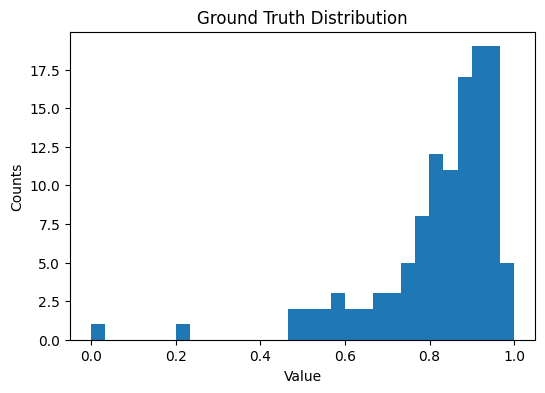

In [69]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.hist(true_label, bins=30)
#plt.xlim(0.8,1)
plt.xlabel("Value")
plt.ylabel("Counts")
plt.title("Ground Truth Distribution")
plt.show()

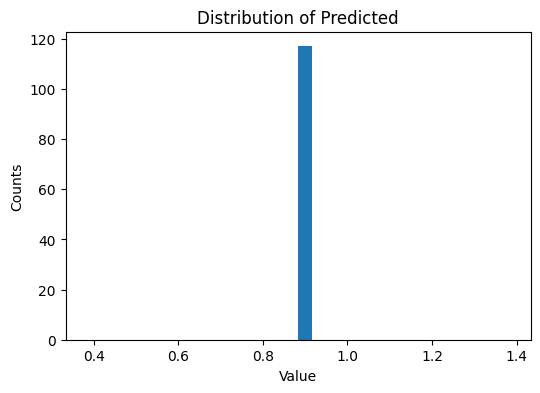

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pred_y, bins=30)
plt.xlabel("Value")
plt.ylabel("Counts")
plt.title("Distribution of Predicted")
plt.show()

# Basic

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from scipy.stats import spearmanr

In [24]:
epsilon=1e-6

In [25]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [26]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [27]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [28]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [38]:
y = logit(creativity_normalized,epsilon)
X = np.column_stack([
    #np.log((newness_normalized+epsilon).astype(float)),
    np.log((surprise_normalized+epsilon).astype(float)),
    np.log((value_normalized+epsilon).astype(float))
])

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23)

In [40]:
kf = KFold(n_splits=5,shuffle=True,random_state=24)
kf.get_n_splits()
kls=[]
jss=[]
wds=[]
for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train = X[train_index]
    X_test = X[test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    model = LinearRegression()
    model.fit(X_train, y_train)
    
    true_label = sigmoid(y_test)
    pred_y = sigmoid(model.predict(X_test))

    kl = kl_divergence(true_label, pred_y)
    # print("Test KL:", kl )
    js = jensenshannon(true_label, pred_y)**2
    # print("Test JS:", js )
    wd = wasserstein_distance(true_label, pred_y)
    # print("Test Wasserstein Distance :", wd )

    kls.append(kl)
    jss.append(js)
    wds.append(wd)

print(f"Average KL is {np.mean(kls)}, std is {np.std(kls)}")
print(f"Average JS is {np.mean(jss)}, std is {np.std(jss)}")
print(f"Average WD is {np.mean(wds)}, std is {np.std(wds)}")

Average KL is 0.014170148299421953, std is 0.005856535799004654
Average JS is 0.003974769430874352, std is 0.0018669211496292078
Average WD is 0.08237921428583916, std is 0.009948653085096145


In [50]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
true_label = sigmoid(y_test)
pred_y = sigmoid(model.predict(X_test))

In [52]:
mse = mean_squared_error(true_label, np.array(pred_y))
print(f"Test Linear Regression model mse: {mse:.4f}")
mae = mean_absolute_error(true_label, pred_y)
print("Test mae:", mae)
RMSE = root_mean_squared_error(true_label, pred_y)
print("Test RMSE:", RMSE)
rho, pval = spearmanr(true_label, pred_y)
print("Test spearman:", rho)
kl = kl_divergence(true_label, pred_y)
print("Test KL:", kl )
js = jensenshannon(true_label, pred_y)**2
print("Test JS:", js )
wd = wasserstein_distance(true_label, pred_y)
print("Test Wasserstein Distance :", wd )

Test Linear Regression model mse: 0.0236
Test mae: 0.09414377522720235
Test RMSE: 0.15360455486856123
Test spearman: -0.0651123552419664
Test KL: 0.020166802485657446
Test JS: 0.005816392017840874
Test Wasserstein Distance : 0.08893212161430586


In [ ]:
rate = 0.1
k = int(len(y_test) * rate)
true_top_idx = np.argsort(y_test)[-k:]
pred_top_idx = np.argsort(model.predict(X_test))[-k:]
hit_rate = len(set(true_top_idx) & set(pred_top_idx)) / k
print(f"Top {rate} Hit Rate with {k} Sample", hit_rate)

In [ ]:
rates = np.linspace(0.01, 0.5, 20) 
hit_rates = topk_hit_rate_curve(y_test, pred_y, rates)
plt.figure()
plt.plot(rates, hit_rates, marker='o')
plt.xlabel("Rate (Top fraction)")
plt.ylabel("Hit Rate")
plt.title("Top-k Hit Rate vs Rate")
plt.grid(True)
plt.show()

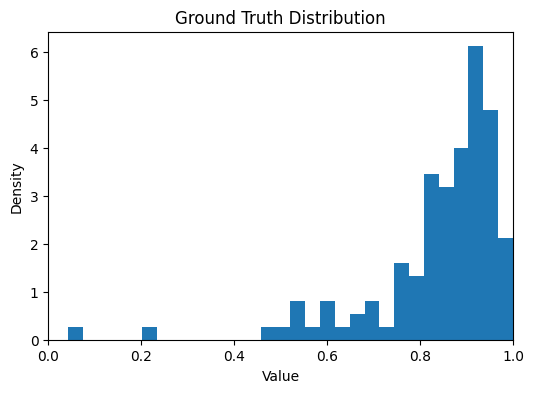

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(true_label, bins=30, density=True)
plt.xlim(0, 1)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Ground Truth Distribution")
plt.show()

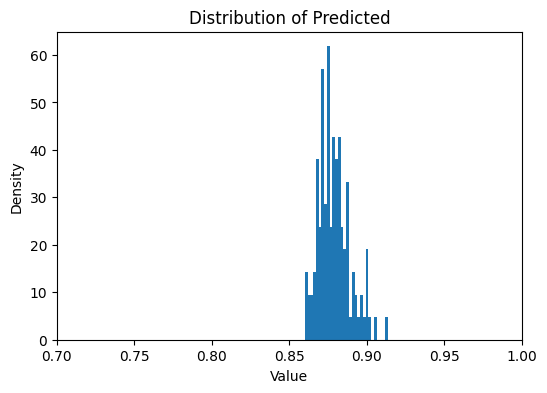

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pred_y, bins=30, density=True)
plt.xlim(0.7, 1)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Distribution of Predicted")
plt.show()

# Splines

In [41]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [42]:
y = logit(creativity_normalized,epsilon)
X = np.column_stack([
    np.log((newness_normalized+epsilon).astype(float)),
    np.log((surprise_normalized+epsilon).astype(float)),
    np.log((value_normalized+epsilon).astype(float))
])

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23)

In [44]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=4,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [45]:
model = make_pipeline(
    preprocess,
    LinearRegression()
)

In [46]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('spline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [47]:
true_label = sigmoid(y_test)
pred_y = sigmoid(model.predict(X_test))

In [50]:
kf = KFold(n_splits=5,shuffle=True,random_state=24)
kf.get_n_splits()
kls=[]
jss=[]
wds=[]
for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train = X[train_index]
    X_test = X[test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    model = make_pipeline(
        preprocess,
        LinearRegression()
    )
    model.fit(X_train, y_train)
    
    true_label = sigmoid(y_test)
    pred_y = sigmoid(model.predict(X_test))

    kl = kl_divergence(true_label, pred_y)
    # print("Test KL:", kl )
    js = jensenshannon(true_label, pred_y)**2
    # print("Test JS:", js )
    wd = wasserstein_distance(true_label, pred_y)
    # print("Test Wasserstein Distance :", wd )

    kls.append(kl)
    jss.append(js)
    wds.append(wd)

print(f"Average KL is {np.mean(kls)}, std is {np.std(kls)}")
print(f"Average JS is {np.mean(jss)}, std is {np.std(jss)}")
print(f"Average WD is {np.mean(wds)}, std is {np.std(wds)}")

Average KL is 0.06853386566787668, std is 0.09963704843518559
Average JS is 0.005510051858337238, std is 0.0018118871805338599
Average WD is 0.06760186871611071, std is 0.011165577218423784


C:\Users\Miss Tiny\AppData\Local\Temp\ipykernel_45536\3196251242.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


In [49]:
mse = mean_squared_error(true_label, np.array(pred_y))
print(f"Test Linear Regression model mse: {mse:.4f}")
mae = mean_absolute_error(true_label, pred_y)
print("Test mae:", mae)
RMSE = root_mean_squared_error(true_label, pred_y)
print("Test RMSE:", RMSE)
rho, pval = spearmanr(true_label, pred_y)
print("Test spearman:", rho)
kl = kl_divergence(true_label, pred_y)
print("Test KL:", kl )
js = jensenshannon(true_label, pred_y)**2
print("Test JS:", js )
wd = wasserstein_distance(true_label, pred_y)
print("Test Wasserstein Distance :", wd )
rate = 0.1
k = int(len(y_test) * rate)
true_top_idx = np.argsort(y_test)[-k:]
pred_top_idx = np.argsort(model.predict(X_test))[-k:]
hit_rate = len(set(true_top_idx) & set(pred_top_idx)) / k
print(f"Top {rate} Hit Rate with {k} Sample:", hit_rate)

Test Linear Regression model mse: 0.0263
Test mae: 0.10283611181150026
Test RMSE: 0.1621404696801457
Test spearman: 0.08622188253982525
Test KL: 0.022841948033892025
Test JS: 0.0067483930831225844
Test Wasserstein Distance : 0.08347969305647047
Top 0.1 Hit Rate with 11 Sample: 0.18181818181818182


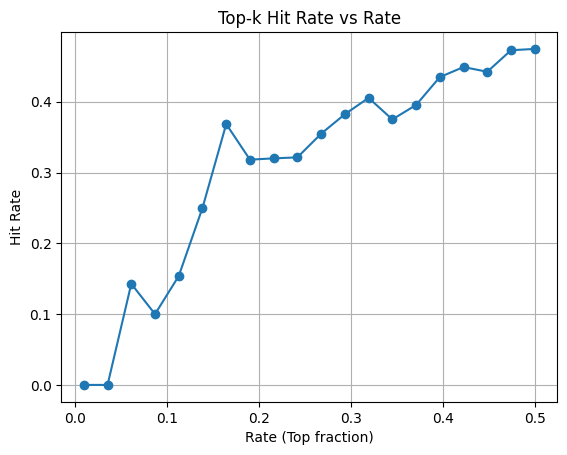

In [61]:
rates = np.linspace(0.01, 0.5, 20) 
hit_rates = topk_hit_rate_curve(y_test, pred_y, rates)
plt.figure()
plt.plot(rates, hit_rates, marker='o')
plt.xlabel("Rate (Top fraction)")
plt.ylabel("Hit Rate")
plt.title("Top-k Hit Rate vs Rate")
plt.grid(True)
plt.show()

In [34]:
hit_rates

[0.0,
 0.0,
 0.14285714285714285,
 0.1,
 0.15384615384615385,
 0.25,
 0.3684210526315789,
 0.3181818181818182,
 0.32,
 0.32142857142857145,
 0.3548387096774194,
 0.38235294117647056,
 0.40540540540540543,
 0.375,
 0.3953488372093023,
 0.43478260869565216,
 0.4489795918367347,
 0.4423076923076923,
 0.4727272727272727,
 0.4745762711864407]

# Neural Network

In [62]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [63]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPRegressor(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=23)
        model.fit(X_train1, y_train1)

        
        true_label = sigmoid(y_val)
        pred_y = sigmoid(model.predict(X_val)) 

        mse = mean_squared_error(true_label, np.array(pred_y))
        #print(f"Test Linear Regression model mse: {mse:.4f}")
        mae = mean_absolute_error(true_label, pred_y)
        #print("Test mae:", mae)
        RMSE = root_mean_squared_error(true_label, pred_y)
        #print("Test RMSE:", RMSE)
        rho, pval = spearmanr(true_label, pred_y)
        #print("Test spearman:", rho)
        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = RMSE
        elif best_score < RMSE:
            best_alpha = alpha
            best_layer = layer
            best_score = RMSE
            
        
        result.append({'alpha':alpha,'layer':layer,'mse':mse,'mae':mae,'RMSE':RMSE,'spearman':rho})
        #print("Test F1:", f1)

In [64]:
model = MLPRegressor(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
model.fit(X_train, y_train)
true_label = sigmoid(y_test)
pred_y = sigmoid(model.predict(X_test))

In [65]:
mse = mean_squared_error(true_label, np.array(pred_y))
print(f"Test Linear Regression model mse: {mse:.4f}")
mae = mean_absolute_error(true_label, pred_y)
print("Test mae:", mae)
RMSE = root_mean_squared_error(true_label, pred_y)
print("Test RMSE:", RMSE)
rho, pval = spearmanr(true_label, pred_y)
print("Test spearman:", rho)
kl = kl_divergence(true_label, pred_y)
print("Test KL:", kl )
js = jensenshannon(true_label, pred_y)**2
print("Test JS:", js )
wd = wasserstein_distance(true_label, pred_y)
print("Test Wasserstein Distance :", wd )
rate = 0.1
k = int(len(y_test) * rate)
true_top_idx = np.argsort(y_test)[-k:]
pred_top_idx = np.argsort(model.predict(X_test))[-k:]
hit_rate = len(set(true_top_idx) & set(pred_top_idx)) / k
print(f"Top {rate} Hit Rate with {k} Sample:", hit_rate)

Test Linear Regression model mse: 0.0242
Test mae: 0.09830354147756662
Test RMSE: 0.15543019565162636
Test spearman: 0.054389943721947706
Test KL: 0.020791528144644935
Test JS: 0.005969759365660825
Test Wasserstein Distance : 0.06734147326904835
Top 0.1 Hit Rate with 11 Sample: 0.09090909090909091


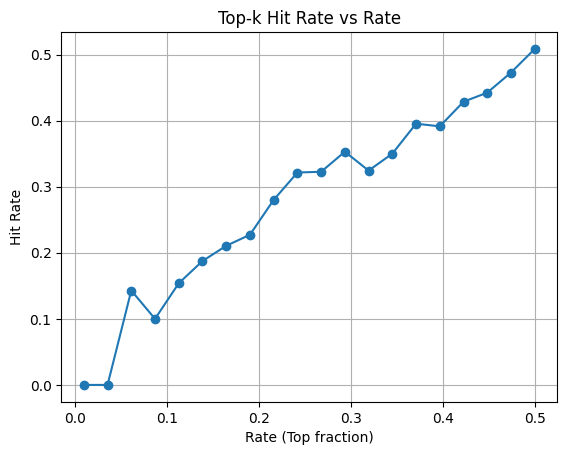

In [39]:
rates = np.linspace(0.01, 0.5, 20) 
hit_rates = topk_hit_rate_curve(true_label, pred_y, rates)
plt.figure()
plt.plot(rates, hit_rates, marker='o')
plt.xlabel("Rate (Top fraction)")
plt.ylabel("Hit Rate")
plt.title("Top-k Hit Rate vs Rate")
plt.grid(True)
plt.show()

In [40]:
hit_rates 

[0.0,
 0.0,
 0.14285714285714285,
 0.1,
 0.15384615384615385,
 0.1875,
 0.21052631578947367,
 0.22727272727272727,
 0.28,
 0.32142857142857145,
 0.3225806451612903,
 0.35294117647058826,
 0.32432432432432434,
 0.35,
 0.3953488372093023,
 0.391304347826087,
 0.42857142857142855,
 0.4423076923076923,
 0.4727272727272727,
 0.5084745762711864]